Configurações do notebook

In [23]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from src.tools import *

root = Path(r"E:\RENASEST Detran")

In [2]:
lista_path = [arquivo for arquivo in root.rglob("*.csv")]
lista_path

[WindowsPath('E:/RENASEST Detran/Acidentes_DadosAbertos_20251112.csv'),
 WindowsPath('E:/RENASEST Detran/Localidade_DadosAbertos_20251112.csv'),
 WindowsPath('E:/RENASEST Detran/TipoVeiculo_DadosAbertos_20251112.csv'),
 WindowsPath('E:/RENASEST Detran/Vitimas_DadosAbertos_20251112.csv')]

# Acidentes

In [3]:
df_acidentes = pd.read_csv(lista_path[0], sep=";", dtype={15: str})
df_acidentes.head()

,num_acidente,chv_localidade,data_acidente,uf_acidente,ano_acidente,mes_acidente,mes_ano_acidente,codigo_ibge,dia_semana,fase_dia,...,lim_velocidade,tp_pista,ind_guardrail,ind_cantcentral,ind_acostamento,qtde_acidente,qtde_acid_com_obitos,qtde_envolvidos,qtde_feridosilesos,qtde_obitos
0,6375817,AC1200401201801,2018-01-02,AC,2018,1,12018,1200401,TERCA-FEIRA,MANHA,...,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,1,0,5,5,0
1,2218504,AC1200203201801,2018-01-31,AC,2018,1,12018,1200203,QUARTA-FEIRA,TARDE,...,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,1,0,1,1,0
2,6534840,AC1200401201801,2018-01-31,AC,2018,1,12018,1200401,QUARTA-FEIRA,TARDE,...,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,1,0,2,2,0
3,5272343,AC1200203201801,2018-01-30,AC,2018,1,12018,1200203,TERCA-FEIRA,TARDE,...,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,1,0,2,2,0
4,5805947,AC1200401201801,2018-01-31,AC,2018,1,12018,1200401,QUARTA-FEIRA,DESCONHECIDO,...,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,NAO INFORMADO,1,0,2,2,0


In [32]:
df_acidentes.dtypes

num_acidente              int64
chv_localidade           object
data_acidente            object
uf_acidente              object
ano_acidente              int64
mes_acidente              int64
mes_ano_acidente          int64
codigo_ibge               int64
dia_semana               object
fase_dia                 object
tp_acidente              object
cond_meteorologica       object
end_acidente             object
num_end_acidente          int64
cep_acidente              int64
bairro_acidente          object
km_via_acidente           int64
latitude_acidente       float64
longitude_acidente      float64
hora_acidente             int64
tp_rodovia               object
cond_pista               object
tp_cruzamento            object
tp_pavimento             object
tp_curva                 object
lim_velocidade           object
tp_pista                 object
ind_guardrail            object
ind_cantcentral          object
ind_acostamento          object
qtde_acidente             int64
qtde_aci

In [4]:
df_acidentes.head().T

,0,1,2,3,4
num_acidente,6375817,2218504,6534840,5272343,5805947
chv_localidade,AC1200401201801,AC1200203201801,AC1200401201801,AC1200203201801,AC1200401201801
data_acidente,2018-01-02,2018-01-31,2018-01-31,2018-01-30,2018-01-31
uf_acidente,AC,AC,AC,AC,AC
ano_acidente,2018,2018,2018,2018,2018
mes_acidente,1,1,1,1,1
mes_ano_acidente,12018,12018,12018,12018,12018
codigo_ibge,1200401,1200203,1200401,1200203,1200401
dia_semana,TERCA-FEIRA,QUARTA-FEIRA,QUARTA-FEIRA,TERCA-FEIRA,QUARTA-FEIRA
fase_dia,MANHA,TARDE,TARDE,TARDE,DESCONHECIDO


In [5]:
df_acidentes.shape

(7868534, 35)

### Atributos categóricos

In [6]:
df_acidentes.select_dtypes('object').describe().T

,count,unique,top,freq
chv_localidade,7868534,304685,MG3106200202410,7599
data_acidente,7868534,2769,2021-01-21,10902
uf_acidente,7868534,27,MG,2017476
dia_semana,7868534,7,SEXTA-FEIRA,1272848
fase_dia,7868534,6,TARDE,2908496
tp_acidente,7868534,16,DESCONHECIDO,1973437
cond_meteorologica,7868534,11,NAO INFORMADO,4170540
end_acidente,7455012,934691,GERAL,99003
bairro_acidente,4614074,47402,CENTRO,561761
tp_rodovia,7868534,5,NAO INFORMADO,4875043


### Atributos numéricos

In [7]:
df_acidentes.drop('num_acidente', axis=1).select_dtypes('number').describe().T

,count,mean,std,min,25%,50%,75%,max
ano_acidente,7868534.0,2.021558e+03,2.150174e+00,2.018000e+03,2.020000e+03,2.022000e+03,2023.0,2.025000e+03
mes_acidente,7868534.0,6.422554e+00,3.429378e+00,1.000000e+00,3.000000e+00,6.000000e+00,9.0,1.200000e+01
mes_ano_acidente,7868534.0,6.624710e+04,3.429353e+04,1.201800e+04,3.202500e+04,6.202400e+04,92024.0,1.220240e+05
codigo_ibge,7868534.0,3.628817e+06,9.338127e+05,0.000000e+00,3.118601e+06,3.522208e+06,4205407.0,5.300108e+06
num_end_acidente,7868534.0,2.614742e+03,1.164218e+04,0.000000e+00,0.000000e+00,0.000000e+00,236.0,9.999900e+04
cep_acidente,7868534.0,2.473378e+06,1.178254e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.0,9.578500e+07
km_via_acidente,7868534.0,1.534261e+01,1.866447e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.0,9.999000e+03
latitude_acidente,3440098.0,-5.587336e+06,1.867505e+08,-6.677848e+09,-2.032768e+01,-1.885692e+01,-0.0,4.595370e+00
longitude_acidente,3439630.0,-3.692008e+06,1.684429e+08,-9.997515e+09,-4.788582e+01,-4.403830e+01,-0.0,-0.000000e+00
hora_acidente,7868534.0,1.594866e+05,1.491303e+05,0.000000e+00,1.000000e+05,1.430000e+05,182300.0,9.999990e+05


### Dados faltantes

In [8]:
df_acidentes.isna().sum()

num_acidente                  0
chv_localidade                0
data_acidente                 0
uf_acidente                   0
ano_acidente                  0
mes_acidente                  0
mes_ano_acidente              0
codigo_ibge                   0
dia_semana                    0
fase_dia                      0
tp_acidente                   0
cond_meteorologica            0
end_acidente             413522
num_end_acidente              0
cep_acidente                  0
bairro_acidente         3254460
km_via_acidente               0
latitude_acidente       4428436
longitude_acidente      4428904
hora_acidente                 0
tp_rodovia                    0
cond_pista                    0
tp_cruzamento                 0
tp_pavimento                  0
tp_curva                      0
lim_velocidade                0
tp_pista                      0
ind_guardrail                 0
ind_cantcentral               0
ind_acostamento               0
qtde_acidente                 0
qtde_aci

# Classes Acidente
### Classe Temporal

In [9]:
df_acidentes_temporal_titulos = ['data_acidente', 'dia_semana', 'fase_dia', 'cond_meteorologica', 'hora_acidente']
df_acidentes_temporal = df_acidentes[df_acidentes_temporal_titulos].copy()
df_acidentes_temporal.head()

,data_acidente,dia_semana,fase_dia,cond_meteorologica,hora_acidente
0,2018-01-02,TERCA-FEIRA,MANHA,CLARO,111500
1,2018-01-31,QUARTA-FEIRA,TARDE,CLARO,150000
2,2018-01-31,QUARTA-FEIRA,TARDE,CLARO,140400
3,2018-01-30,TERCA-FEIRA,TARDE,CLARO,164000
4,2018-01-31,QUARTA-FEIRA,DESCONHECIDO,CLARO,0


In [10]:
valores_data_hora = (
    df_acidentes_temporal['data_acidente'].astype(str) + ' ' + 
    df_acidentes_temporal['hora_acidente'].astype(str).str.zfill(6)
)

serie_timestamp = pd.to_datetime(valores_data_hora, format="%Y-%m-%d %H%M%S", errors='coerce')
df_acidentes_temporal.index = serie_timestamp
df_acidentes_temporal.index.name = 'timestamp'
df_acidentes_temporal.drop(columns=['data_acidente', 'hora_acidente'], inplace=True)
df_acidentes_temporal.head()

,dia_semana,fase_dia,cond_meteorologica
timestamp,,,
2018-01-02 11:15:00,TERCA-FEIRA,MANHA,CLARO
2018-01-31 15:00:00,QUARTA-FEIRA,TARDE,CLARO
2018-01-31 14:04:00,QUARTA-FEIRA,TARDE,CLARO
2018-01-30 16:40:00,TERCA-FEIRA,TARDE,CLARO
2018-01-31 00:00:00,QUARTA-FEIRA,DESCONHECIDO,CLARO


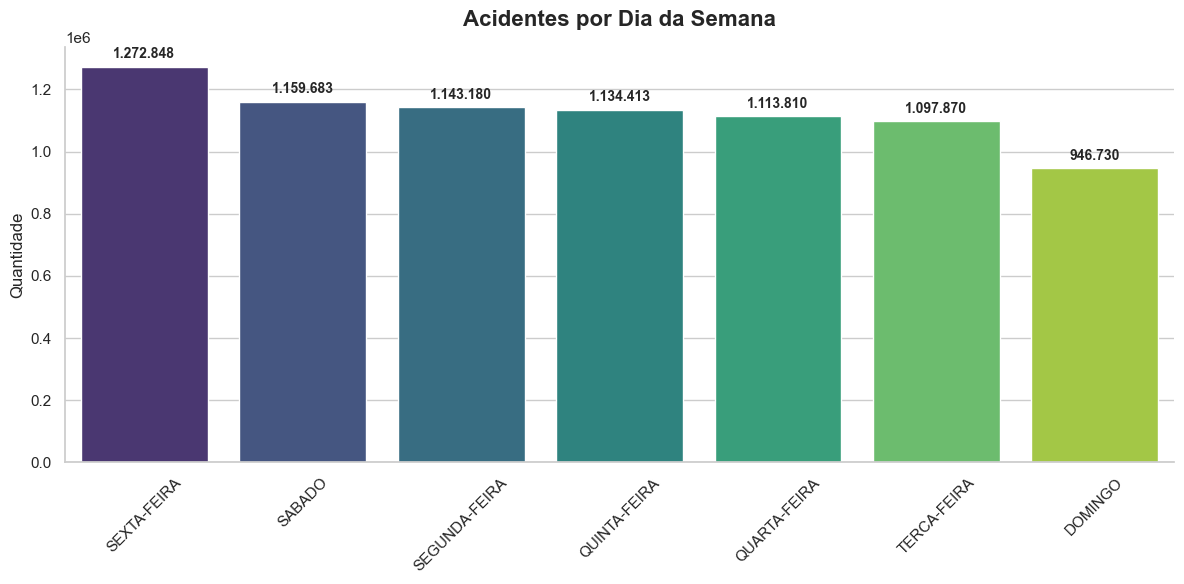

In [24]:
plot_counts(df_acidentes_temporal, 'dia_semana', 'Acidentes por Dia da Semana')

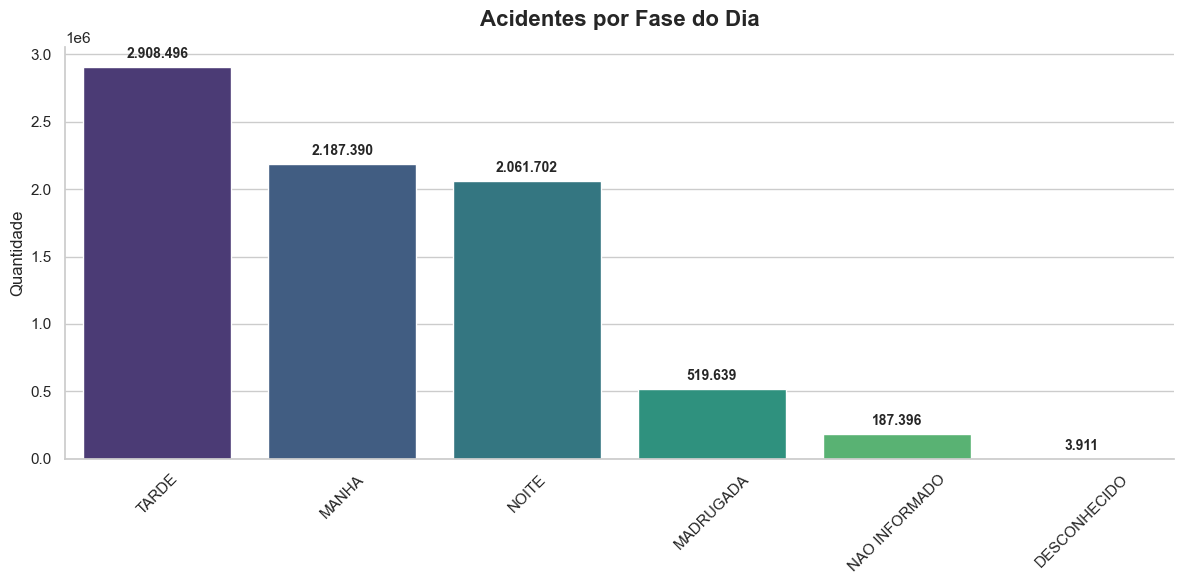

In [25]:
plot_counts(df_acidentes_temporal, 'fase_dia', 'Acidentes por Fase do Dia')

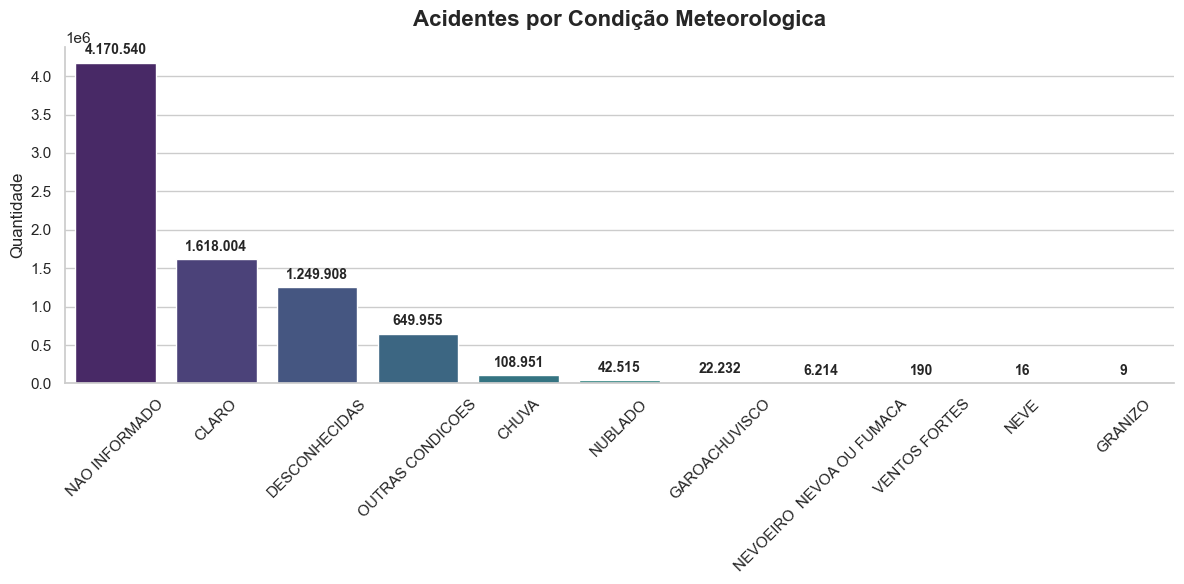

In [26]:
plot_counts(df_acidentes_temporal, 'cond_meteorologica', 'Acidentes por Condição Meteorologica')

# Localidade

In [27]:
df_localidade = pd.read_csv(lista_path[1], sep=";")
df_localidade.head()

,chv_localidade,ano_referencia,mes_referencia,mes_ano_referencia,regiao,uf,codigo_ibge,municipio,regiao_metropolitana,qtde_habitantes,frota_total,frota_circulante
0,AC1200328201801,2018,1,12018,NORTE,AC,1200328,JORDAO,nao,8011,116,81
1,AC1200385201801,2018,1,12018,NORTE,AC,1200385,PLACIDO DE CASTRO,nao,19111,4887,3633
2,AC1200708201801,2018,1,12018,NORTE,AC,1200708,XAPURI,nao,18684,4003,2899
3,AC1200401201801,2018,1,12018,NORTE,AC,1200401,RIO BRANCO,nao,393618,159867,114542
4,AC1200344201801,2018,1,12018,NORTE,AC,1200344,MANOEL URBANO,nao,9141,1150,963


In [31]:
df_localidade.dtypes

chv_localidade          object
ano_referencia           int64
mes_referencia           int64
mes_ano_referencia       int64
regiao                  object
uf                      object
codigo_ibge              int64
municipio               object
regiao_metropolitana    object
qtde_habitantes          int64
frota_total              int64
frota_circulante         int64
dtype: object

In [29]:
df_localidade.isna().sum()

chv_localidade          0
ano_referencia          0
mes_referencia          0
mes_ano_referencia      0
regiao                  0
uf                      0
codigo_ibge             0
municipio               0
regiao_metropolitana    0
qtde_habitantes         0
frota_total             0
frota_circulante        0
dtype: int64

# Veículos

In [33]:
df_tipo_veiculo = pd.read_csv(lista_path[2], sep=";")
df_tipo_veiculo.head()

,num_acidente,tipo_veiculo,ind_veic_estrangeiro,qtde_veiculos
0,48,NAO INFORMADO,NAO INFORMADO,1
1,175,NAO INFORMADO,NAO INFORMADO,1
2,185,NAO INFORMADO,NAO INFORMADO,1
3,192,NAO INFORMADO,NAO INFORMADO,1
4,216,NAO INFORMADO,NAO INFORMADO,1


In [34]:
df_tipo_veiculo.dtypes

num_acidente             int64
tipo_veiculo            object
ind_veic_estrangeiro    object
qtde_veiculos            int64
dtype: object

In [ ]:
df_tipo_veiculo.value_counts('tipo_veiculo')

# Vítimas

In [35]:
df_vitimas = pd.read_csv(lista_path[3], sep=";")
df_vitimas.head()

,num_acidente,chv_localidade,data_acidente,uf_acidente,ano_acidente,mes_acidente,mes_ano_acidente,faixa_idade,genero,tp_envolvido,gravidade_lesao,equip_seguranca,ind_motorista,susp_alcool,qtde_envolvidos,qtde_feridosilesos,qtde_obitos
0,1107770,AC1200401201801,2018-01-31,AC,2018,1,12018,ENTRE 60 E 64 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
1,5840911,AC1200401201801,2018-01-03,AC,2018,1,12018,ENTRE 60 E 64 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
2,2996634,AC1200401201801,2018-01-04,AC,2018,1,12018,ENTRE 25 E 29 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
3,3659782,AC1200401201801,2018-01-26,AC,2018,1,12018,ENTRE 25 E 29 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0
4,2033351,AC1200401201801,2018-01-18,AC,2018,1,12018,ENTRE 25 E 29 ANOS,MASCULINO,MOTORISTA,NAO INFORMADO,NAO INFORMADO,SIM,NAO INFORMADO,1,1,0


In [36]:
df_vitimas.dtypes

num_acidente           int64
chv_localidade        object
data_acidente         object
uf_acidente           object
ano_acidente           int64
mes_acidente           int64
mes_ano_acidente       int64
faixa_idade           object
genero                object
tp_envolvido          object
gravidade_lesao       object
equip_seguranca       object
ind_motorista         object
susp_alcool           object
qtde_envolvidos        int64
qtde_feridosilesos     int64
qtde_obitos            int64
dtype: object